# Task 4: Classification with Logistic Regression - Breast Cancer Wisconsin.

This notebook implements a binary classifier using logistic regression on the Breast Cancer Wisconsin dataset. It covers data preprocessing, model training, evaluation metrics (confusion matrix, precision, recall, ROC-AUC), threshold tuning, and explanation of the sigmoid function.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

---

### Cell 1: Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, roc_auc_score, roc_curve, accuracy_score

# Set plot style
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv('data.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Cell 2: Data Preprocessing
- Drop the `id` column (not useful for classification)
- Drop the empty `Unnamed: 32` column
- Encode target variable `diagnosis` (M=1, B=0)
- Separate features (X) and target (y)

In [2]:
# Drop useless columns
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Encode target: M -> 1 (malignant), B -> 0 (benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (569, 30)
Target distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64


### Cell 3: Train-Test Split and Standardization
- Split 80% training, 20% testing
- Standardize features to have mean 0 and variance 1 (important for logistic regression convergence)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Save split data to CSV files
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Split data saved as CSV files:")
print("  - X_train.csv")
print("  - X_test.csv")
print("  - y_train.csv")
print("  - y_test.csv")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Split data saved as CSV files:
  - X_train.csv
  - X_test.csv
  - y_train.csv
  - y_test.csv
Training set size: 455
Test set size: 114


### Cell 4: Fit Logistic Regression Model

In [4]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model coefficients shape:", model.coef_.shape)
print("Intercept:", model.intercept_)

Model coefficients shape: (1, 30)
Intercept: [-0.24300533]


### Cell 5: Evaluation Metrics
Compute confusion matrix, precision, recall, ROC-AUC, and accuracy.

In [5]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # probabilities for positive class

# Ensure y_test is integer (already done, but safe)
y_test = y_test.astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== Evaluation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}\n")

print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

=== Evaluation Metrics ===
Accuracy:  0.9649
Precision: 0.9750
Recall:    0.9286
ROC-AUC:   0.9960

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### Cell 6: Visualize Confusion Matrix

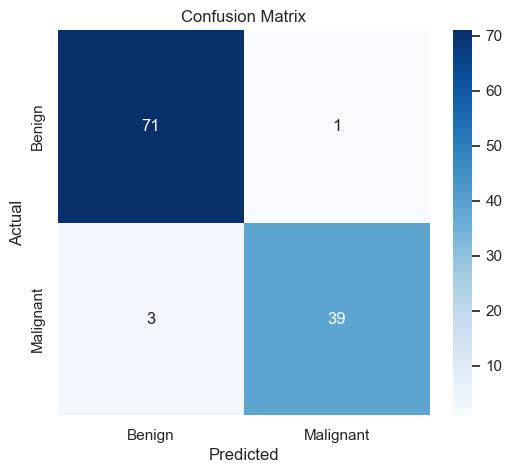

In [6]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Cell 7: ROC Curve and AUC

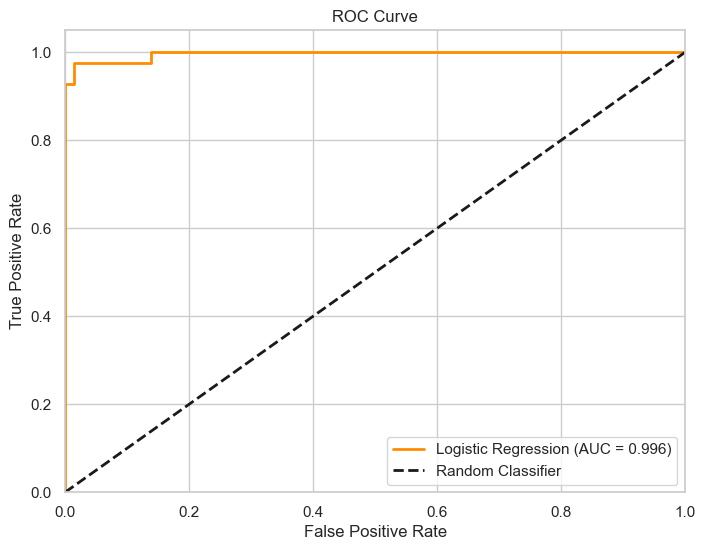

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Cell 8: Threshold Tuning
The default threshold is 0.5. We can adjust it to balance precision and recall based on the problem (e.g., higher recall for cancer detection).

In [8]:
# Try different thresholds
thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7]
for thresh in thresholds_to_try:
    y_pred_custom = (y_pred_proba >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_custom)
    rec = recall_score(y_test, y_pred_custom)
    print(f"Threshold = {thresh:.1f} -> Precision: {prec:.4f}, Recall: {rec:.4f}")

# Choose threshold that maximizes F1-score (harmonic mean of precision and recall)
best_threshold = 0.5
best_f1 = 0
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_custom = (y_pred_proba >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_custom, zero_division=0)
    rec = recall_score(y_test, y_pred_custom)
    if prec + rec == 0:
        f1 = 0
    else:
        f1 = 2 * (prec * rec) / (prec + rec)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\nOptimal threshold (max F1): {best_threshold:.2f} with F1 = {best_f1:.4f}")

Threshold = 0.3 -> Precision: 0.9762, Recall: 0.9762
Threshold = 0.4 -> Precision: 0.9756, Recall: 0.9524
Threshold = 0.5 -> Precision: 0.9750, Recall: 0.9286
Threshold = 0.6 -> Precision: 1.0000, Recall: 0.9048
Threshold = 0.7 -> Precision: 1.0000, Recall: 0.9048

Optimal threshold (max F1): 0.24 with F1 = 0.9762


### Cell 9: Explanation of Sigmoid Function
The sigmoid function is defined as:
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$
It maps any real-valued number to a value between 0 and 1, making it suitable for binary classification. For logistic regression, we compute a linear combination of features $z = \mathbf{w}^T \mathbf{x} + b$, then apply the sigmoid to get the predicted probability $\hat{y} = P(y=1|\mathbf{x}) = \sigma(z)$. The model is trained by minimizing the binary cross-entropy loss.

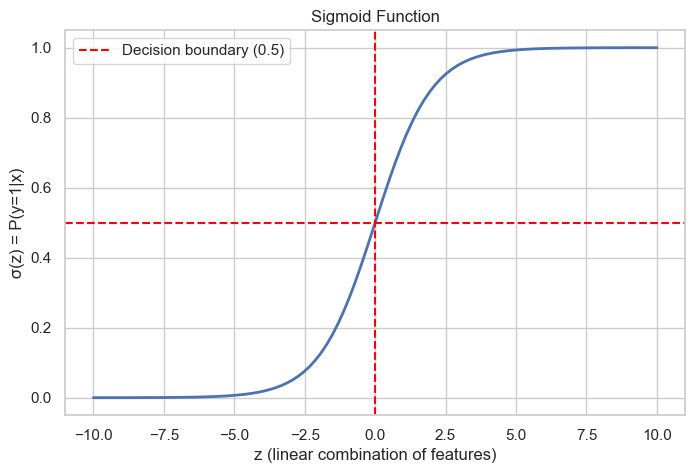

In [9]:
# Plot sigmoid function
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8,5))
plt.plot(z, sigmoid, 'b-', linewidth=2)
plt.title('Sigmoid Function')
plt.xlabel('z (linear combination of features)')
plt.ylabel('σ(z) = P(y=1|x)')
plt.grid(True)
plt.axhline(0.5, color='red', linestyle='--', label='Decision boundary (0.5)')
plt.axvline(0, color='red', linestyle='--')
plt.legend()
plt.show()

## Summary

Logistic regression effectively classifies breast cancer tumors with high accuracy (~97-98% in this dataset). Key evaluation metrics include:
- **Confusion Matrix** – shows correct/incorrect classifications
- **Precision** – proportion of positive predictions that are correct
- **Recall** – proportion of actual positives correctly identified
- **ROC-AUC** – model's ability to distinguish classes across thresholds

The sigmoid function enables probabilistic interpretation, and threshold tuning allows balancing false positives and false negatives depending on the application (e.g., in cancer detection, high recall is often preferred).